In [5]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.model_selection import train_test_split, cross_validate, KFold, GridSearchCV
from sklearn.model_selection import cross_val_score, GroupKFold, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report

In [6]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
df = pd.read_csv("../data/books.csv", on_bad_lines="skip")
print("rows:", len(df))
print("columns:", df.shape[1])
df.head()

rows: 11123
columns: 12


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher;;;
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9.780440e+12,eng,652.0,2095690.0,27591.0,9/16/2006,Scholastic Inc.;;;
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9.780439e+12,eng,870.0,2153167.0,29221.0,9/1/2004,Scholastic Inc.;;;
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9.780440e+12,eng,352.0,6333.0,244.0,11/1/2003,Scholastic;;;
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9.780440e+12,eng,435.0,2339585.0,36325.0,5/1/2004,Scholastic Inc.;;;
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9.780440e+12,eng,2690.0,41428.0,164.0,9/13/2004,Scholastic;;;


In [8]:
df.columns = df.columns.str.strip()
print(list(df.columns))

['bookID', 'title', 'authors', 'average_rating', 'isbn', 'isbn13', 'language_code', 'num_pages', 'ratings_count', 'text_reviews_count', 'publication_date', 'publisher;;;']


In [9]:
df = df.rename(columns={"publisher;;;": "publisher"})
df["publisher"] = df["publisher"].str.replace(";;;", "", regex=False)
df[["publisher"]].head()

,publisher
0,Scholastic Inc.
1,Scholastic Inc.
2,Scholastic
3,Scholastic Inc.
4,Scholastic


In [10]:
is_real_id = df["bookID"].astype(str).str.isdigit()
print("rows before:", len(df))
df = df[is_real_id].copy()
print("rows after removing broken rows:", len(df))

rows before: 11123
rows after removing broken rows: 11094


In [11]:
df["title"] = df["title"].str.strip()
df["authors"] = df["authors"].str.strip()
df["publisher"] = df["publisher"].str.strip()
df["language_code"] = df["language_code"].str.strip()

In [12]:
df["average_rating"] = pd.to_numeric(df["average_rating"], errors="coerce")
df["num_pages"] = pd.to_numeric(df["num_pages"], errors="coerce")
df["ratings_count"] = pd.to_numeric(df["ratings_count"], errors="coerce")
df["text_reviews_count"] = pd.to_numeric(df["text_reviews_count"], errors="coerce")
df.dtypes

bookID                 object
title                  object
authors                object
average_rating        float64
isbn                   object
isbn13                float64
language_code          object
num_pages             float64
ratings_count         float64
text_reviews_count    float64
publication_date       object
publisher              object
dtype: object

In [13]:
df["pub_date"] = pd.to_datetime(df["publication_date"], format="%m/%d/%Y", errors="coerce")
df["pub_year"] = df["pub_date"].dt.year
print("dates that could not be read:", int(df["pub_date"].isna().sum()))

dates that could not be read: 2


In [14]:
print("books with zero ratings:", int((df["ratings_count"] == 0).sum()))
df = df[df["ratings_count"] > 0].copy()
print("rows after removing zero-rating books:", len(df))

books with zero ratings: 78
rows after removing zero-rating books: 11016


In [15]:
not_a_book = df["authors"].str.upper().str.contains("NOT A BOOK", na=False)
print("not a book records:", int(not_a_book.sum()))
df = df[~not_a_book].copy()
print("rows after removing them:", len(df))

not a book records: 4
rows after removing them: 11012


In [16]:
df["num_pages"] = df["num_pages"].replace(0, np.nan)
print("books with unknown page count:", int(df["num_pages"].isna().sum()))

books with unknown page count: 72


In [17]:
df = df.dropna(subset=["average_rating"]).reset_index(drop=True)
df["first_author"] = df["authors"].str.split("/").str[0].str.strip()
print("final clean shape:", df.shape)
df.head()

final clean shape: (11012, 15)


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,pub_date,pub_year,first_author
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9.780440e+12,eng,652.0,2095690.0,27591.0,9/16/2006,Scholastic Inc.,2006-09-16,2006.0,J.K. Rowling
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9.780439e+12,eng,870.0,2153167.0,29221.0,9/1/2004,Scholastic Inc.,2004-09-01,2004.0,J.K. Rowling
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9.780440e+12,eng,352.0,6333.0,244.0,11/1/2003,Scholastic,2003-11-01,2003.0,J.K. Rowling
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9.780440e+12,eng,435.0,2339585.0,36325.0,5/1/2004,Scholastic Inc.,2004-05-01,2004.0,J.K. Rowling
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9.780440e+12,eng,2690.0,41428.0,164.0,9/13/2004,Scholastic,2004-09-13,2004.0,J.K. Rowling


In [18]:
overview = pd.DataFrame()
overview["dtype"] = df.dtypes.astype(str)
overview["unique_values"] = df.nunique()
overview["percent_missing"] = (df.isnull().mean() * 100).round(2)
overview

,dtype,unique_values,percent_missing
bookID,object,11012,0.00
title,object,10241,0.00
authors,object,6562,0.00
average_rating,float64,208,0.00
isbn,object,11012,0.00
isbn13,float64,11012,0.00
language_code,object,26,0.00
num_pages,float64,993,0.65
ratings_count,float64,5290,0.00
text_reviews_count,float64,1822,0.00


In [19]:
df.describe().round(2)

,average_rating,isbn13,num_pages,ratings_count,text_reviews_count,pub_date,pub_year
count,11012.00,1.101200e+04,10940.00,11012.00,11012.00,11010,11010.00
mean,3.94,9.759664e+12,339.23,18121.44,547.35,2000-09-06 08:20:39.891008128,2000.19
min,1.00,8.987060e+09,1.00,1.00,0.00,1900-01-01 00:00:00,1900.00
25%,3.78,9.780345e+12,197.00,111.00,9.00,1998-08-08 12:00:00,1998.00
50%,3.96,9.780573e+12,302.00,768.00,48.00,2003-03-03 00:00:00,2003.00
75%,4.14,9.780872e+12,416.00,5082.75,242.00,2005-10-01 00:00:00,2005.00
max,5.00,9.790008e+12,6576.00,4597666.00,94265.00,2020-03-31 00:00:00,2020.00
std,0.29,4.451977e+11,240.33,113050.57,2589.02,NaN,8.21


In [20]:
print("exact duplicate rows:", int(df.duplicated().sum()))
print("same title and author pairs:", int(df.duplicated(subset=["title", "authors"]).sum()))

exact duplicate rows: 0
same title and author pairs: 308


In [21]:
print("text reviews never exceed ratings:", bool((df["text_reviews_count"] <= df["ratings_count"]).all()))
print("rows with missing page count:", int(df["num_pages"].isna().sum()))
print("duplicate isbn values:", int(df["isbn"].duplicated().sum()))

text reviews never exceed ratings: True
rows with missing page count: 72
duplicate isbn values: 0


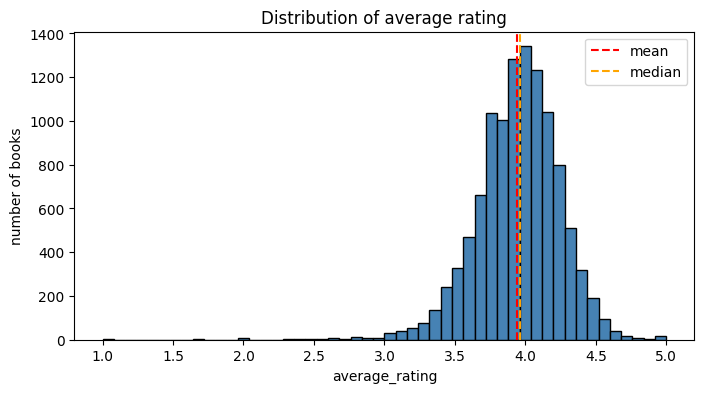

In [22]:
plt.figure(figsize=(8, 4))
plt.hist(df["average_rating"], bins=50, color="steelblue", edgecolor="black")
plt.axvline(df["average_rating"].mean(), color="red", linestyle="--", label="mean")
plt.axvline(df["average_rating"].median(), color="orange", linestyle="--", label="median")
plt.xlabel("average_rating")
plt.ylabel("number of books")
plt.title("Distribution of average rating")
plt.legend()
plt.show()

In [23]:
rated_4_or_more = (df["average_rating"] >= 4).sum()
rated_3_to_4 = ((df["average_rating"] >= 3) & (df["average_rating"] < 4)).sum()
rated_below_3 = (df["average_rating"] < 3).sum()
print("rated 4.0 or more:", int(rated_4_or_more))
print("rated 3.0 to 4.0:", int(rated_3_to_4))
print("rated below 3.0:", int(rated_below_3))

rated 4.0 or more: 4915
rated 3.0 to 4.0: 6042
rated below 3.0: 55


In [24]:
five_star = df[df["average_rating"] == 5.0]
print("books with a perfect 5.0 rating:", len(five_star))
print("their median ratings_count:", int(five_star["ratings_count"].median()))
print("overall median ratings_count:", int(df["ratings_count"].median()))

books with a perfect 5.0 rating: 17
their median ratings_count: 2
overall median ratings_count: 768


In [25]:
print(df["num_pages"].describe().round(1))
print("books over 1000 pages:", int((df["num_pages"] >= 1000).sum()))

count    10940.0
mean       339.2
std        240.3
min          1.0
25%        197.0
50%        302.0
75%        416.0
max       6576.0
Name: num_pages, dtype: float64
books over 1000 pages: 215


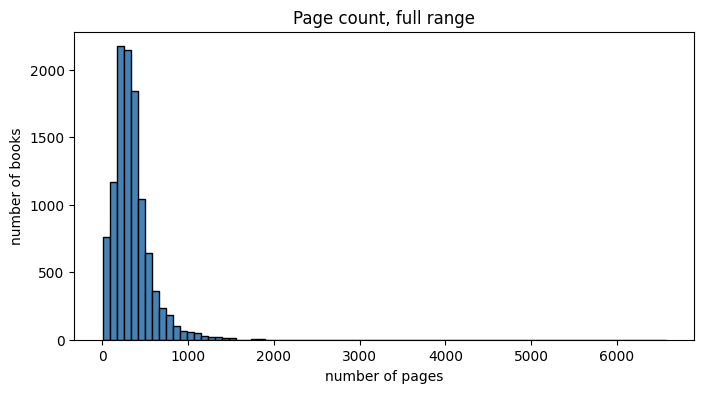

In [26]:
plt.figure(figsize=(8, 4))
plt.hist(df["num_pages"].dropna(), bins=80, color="steelblue", edgecolor="black")
plt.xlabel("number of pages")
plt.ylabel("number of books")
plt.title("Page count, full range")
plt.show()

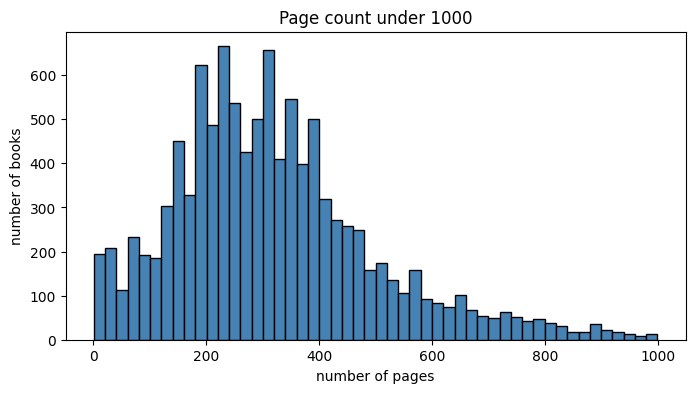

In [27]:
short_books = df[df["num_pages"] < 1000]
plt.figure(figsize=(8, 4))
plt.hist(short_books["num_pages"].dropna(), bins=50, color="steelblue", edgecolor="black")
plt.xlabel("number of pages")
plt.ylabel("number of books")
plt.title("Page count under 1000")
plt.show()

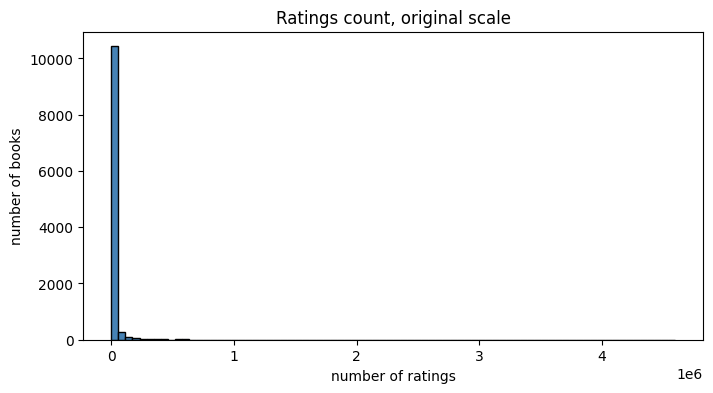

In [28]:
plt.figure(figsize=(8, 4))
plt.hist(df["ratings_count"], bins=80, color="steelblue", edgecolor="black")
plt.xlabel("number of ratings")
plt.ylabel("number of books")
plt.title("Ratings count, original scale")
plt.show()

count      11012.0
mean       18121.0
std       113051.0
min            1.0
25%          111.0
50%          768.0
75%         5083.0
max      4597666.0
Name: ratings_count, dtype: float64


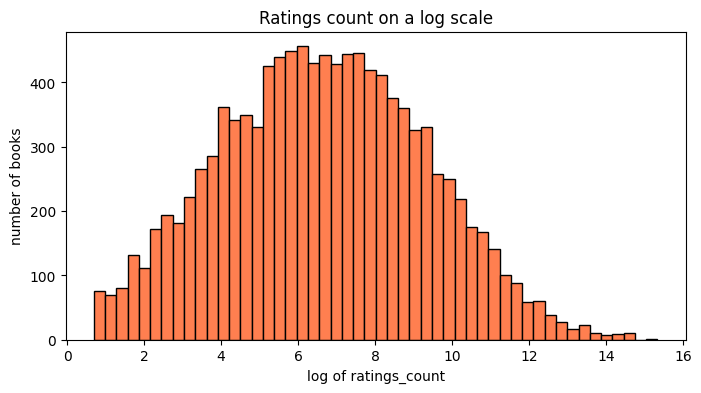

In [29]:
print(df["ratings_count"].describe().round(0))
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(df["ratings_count"]), bins=50, color="coral", edgecolor="black")
plt.xlabel("log of ratings_count")
plt.ylabel("number of books")
plt.title("Ratings count on a log scale")
plt.show()

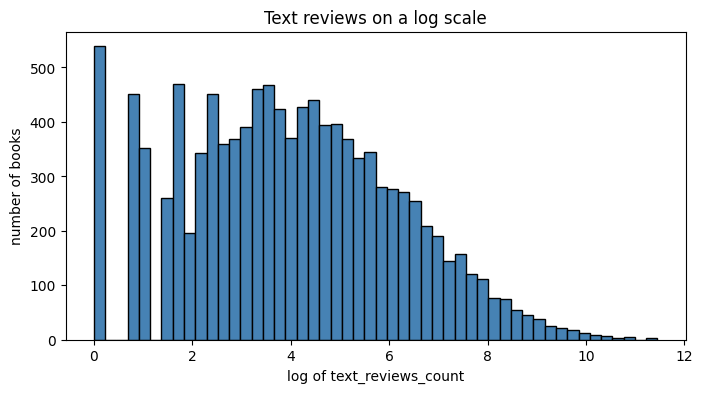

In [30]:
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(df["text_reviews_count"]), bins=50, color="steelblue", edgecolor="black")
plt.xlabel("log of text_reviews_count")
plt.ylabel("number of books")
plt.title("Text reviews on a log scale")
plt.show()

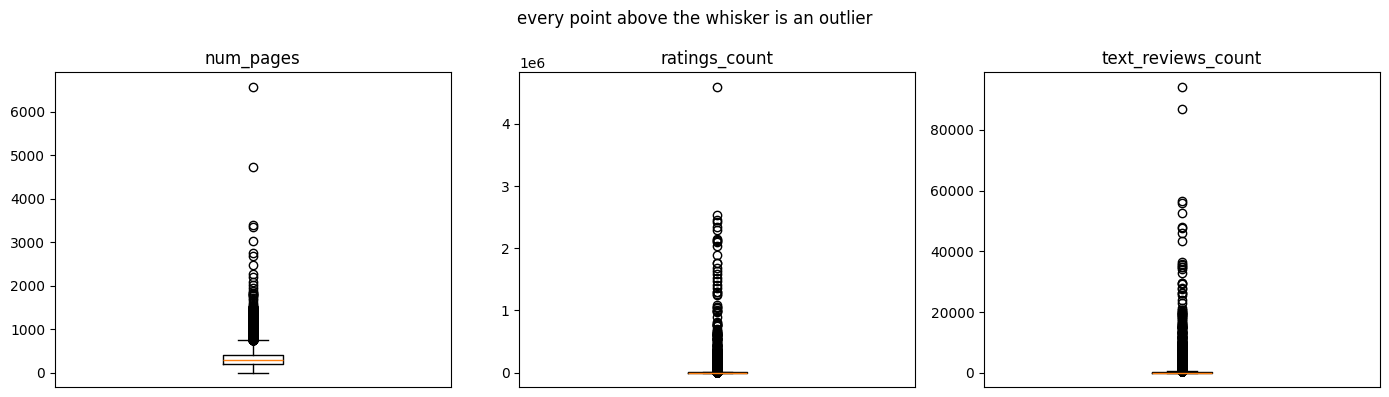

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].boxplot(df["num_pages"].dropna())
axes[0].set_title("num_pages")
axes[0].set_xticks([])
axes[1].boxplot(df["ratings_count"].dropna())
axes[1].set_title("ratings_count")
axes[1].set_xticks([])
axes[2].boxplot(df["text_reviews_count"].dropna())
axes[2].set_title("text_reviews_count")
axes[2].set_xticks([])
plt.suptitle("every point above the whisker is an outlier")
plt.tight_layout()
plt.show()

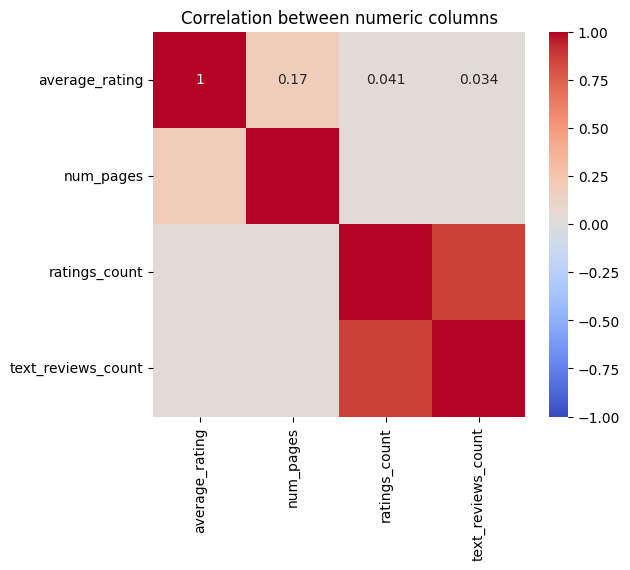

In [32]:
numeric_columns = ["average_rating", "num_pages", "ratings_count", "text_reviews_count"]
correlation = df[numeric_columns].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between numeric columns")
plt.show()

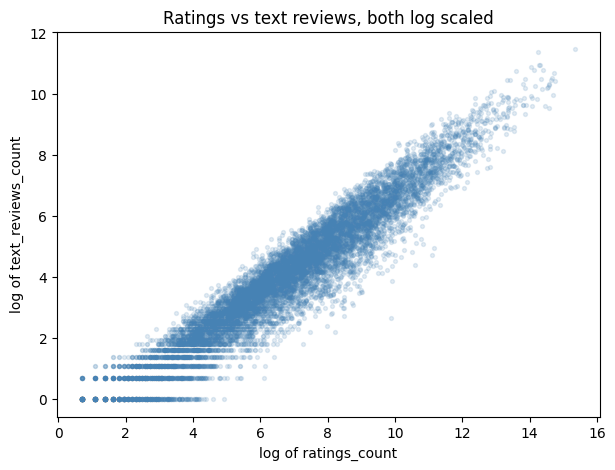

In [33]:
plt.figure(figsize=(7, 5))
plt.scatter(np.log1p(df["ratings_count"]), np.log1p(df["text_reviews_count"]), alpha=0.15, s=8, color="steelblue")
plt.xlabel("log of ratings_count")
plt.ylabel("log of text_reviews_count")
plt.title("Ratings vs text reviews, both log scaled")
plt.show()

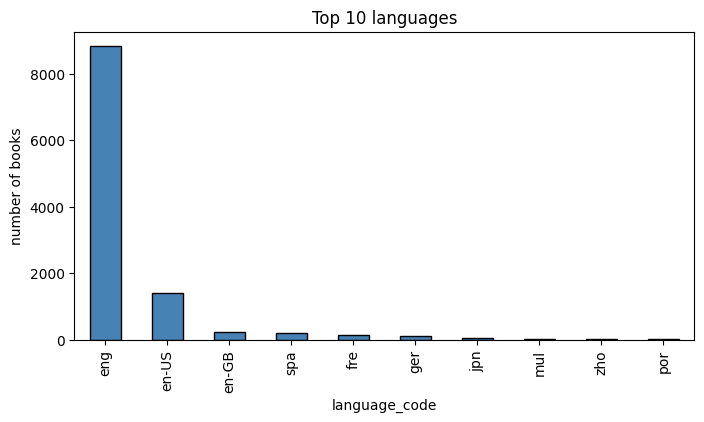

In [34]:
top_languages = df["language_code"].value_counts().head(10)
plt.figure(figsize=(8, 4))
top_languages.plot.bar(color="steelblue", edgecolor="black")
plt.xlabel("language_code")
plt.ylabel("number of books")
plt.title("Top 10 languages")
plt.show()

                mean  count
language_code              
fre            3.971    140
ger            3.946     96
eng            3.945   8820
en-GB          3.925    213
spa            3.924    212
en-US          3.916   1403


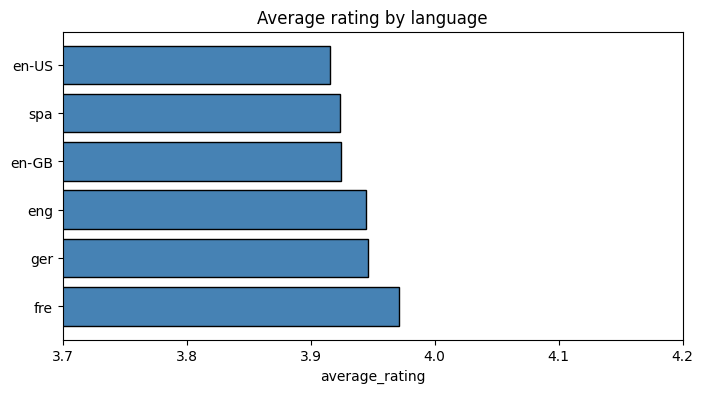

In [35]:
lang_stats = df.groupby("language_code")["average_rating"].agg(["mean", "count"])
lang_stats = lang_stats[lang_stats["count"] >= 50].sort_values("mean", ascending=False).head(6)
print(lang_stats.round(3))
plt.figure(figsize=(8, 4))
plt.barh(lang_stats.index, lang_stats["mean"], color="steelblue", edgecolor="black")
plt.xlim(3.7, 4.2)
plt.xlabel("average_rating")
plt.title("Average rating by language")
plt.show()

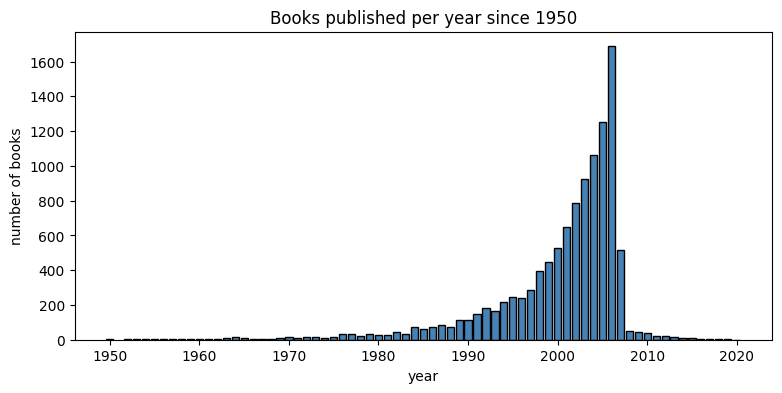

In [36]:
books_per_year = df["pub_year"].dropna().astype(int).value_counts().sort_index()
books_per_year = books_per_year[books_per_year.index >= 1950]
plt.figure(figsize=(9, 4))
plt.bar(books_per_year.index, books_per_year.values, color="steelblue", edgecolor="black")
plt.xlabel("year")
plt.ylabel("number of books")
plt.title("Books published per year since 1950")
plt.show()

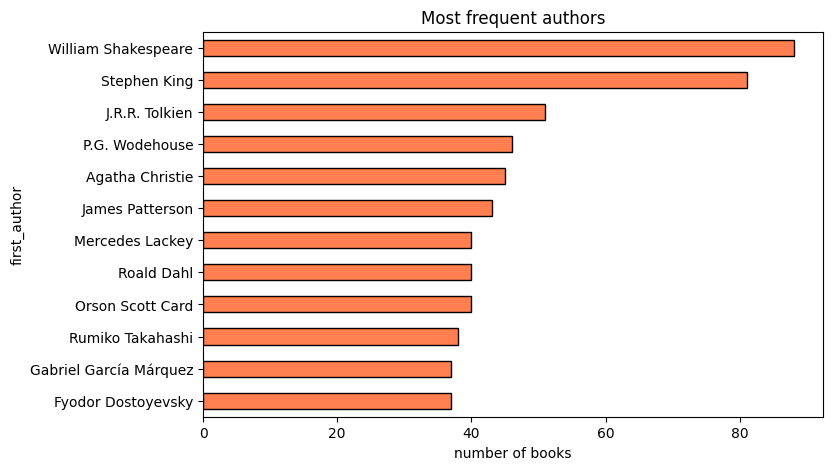

In [37]:
top_authors = df["first_author"].value_counts().head(12)
plt.figure(figsize=(8, 5))
top_authors.sort_values().plot.barh(color="coral", edgecolor="black")
plt.xlabel("number of books")
plt.title("Most frequent authors")
plt.show()

title
The Brothers Karamazov        9
The Iliad                     9
'Salem's Lot                  8
The Odyssey                   8
Anna Karenina                 8
Gulliver's Travels            8
The Picture of Dorian Gray    7
A Midsummer Night's Dream     7
Collected Stories             6
Romeo and Juliet              6
Macbeth                       6
The Histories                 6
Sense and Sensibility         6
The Secret Garden             6
The Great Gatsby              6
Name: count, dtype: int64


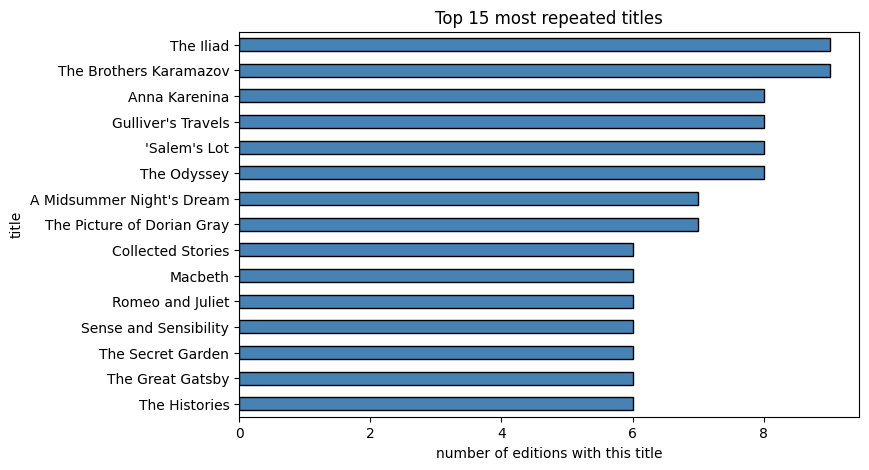

In [38]:
top_repeated = df["title"].value_counts().head(15)
print(top_repeated)
plt.figure(figsize=(8, 5))
top_repeated.sort_values().plot.barh(color="steelblue", edgecolor="black")
plt.xlabel("number of editions with this title")
plt.title("Top 15 most repeated titles")
plt.show()

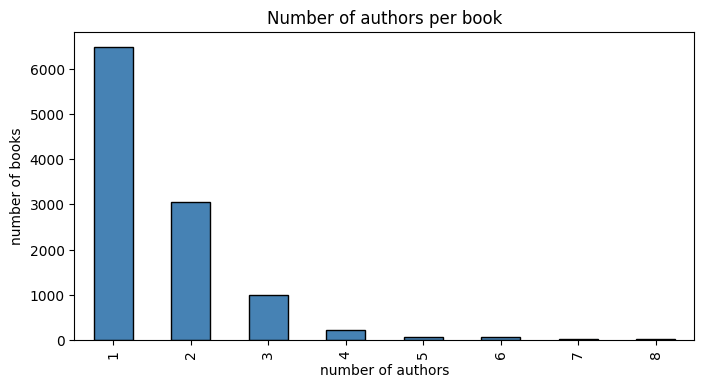

In [39]:
df["num_authors"] = df["authors"].str.count("/") + 1
author_counts = df["num_authors"].value_counts().sort_index().head(8)
plt.figure(figsize=(8, 4))
author_counts.plot.bar(color="steelblue", edgecolor="black")
plt.xlabel("number of authors")
plt.ylabel("number of books")
plt.title("Number of authors per book")
plt.show()

num_authors
1    3.920
2    3.966
3    3.998
4    4.056
5    4.006
6    3.997
Name: average_rating, dtype: float64


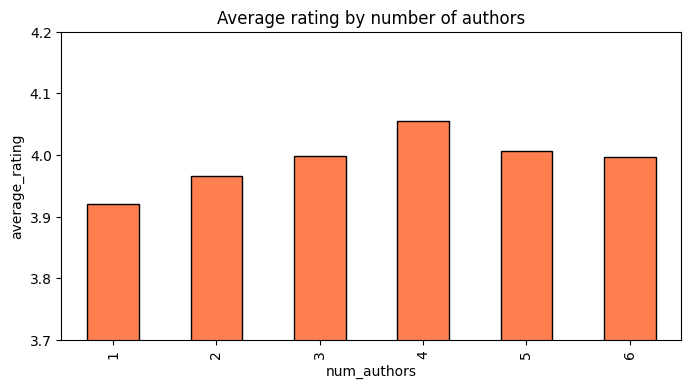

In [40]:
rating_by_authors = df.groupby("num_authors")["average_rating"].mean().head(6)
print(rating_by_authors.round(3))
plt.figure(figsize=(8, 4))
rating_by_authors.plot.bar(color="coral", edgecolor="black")
plt.ylim(3.7, 4.2)
plt.ylabel("average_rating")
plt.title("Average rating by number of authors")
plt.show()

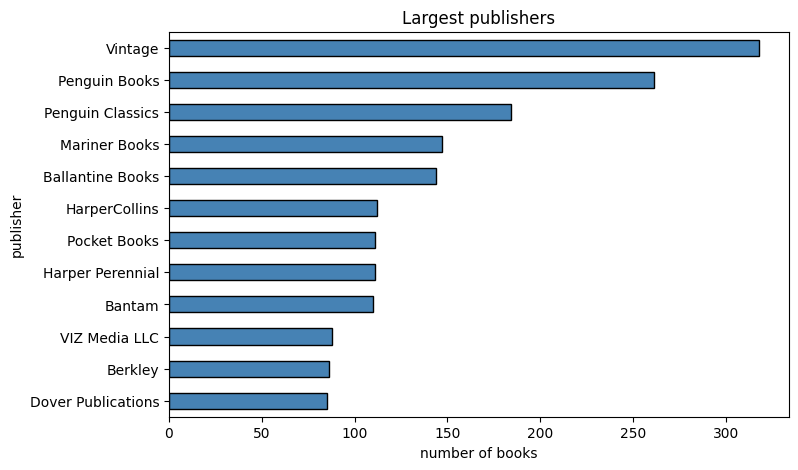

In [41]:
top_publishers = df["publisher"].value_counts().head(12)
plt.figure(figsize=(8, 5))
top_publishers.sort_values().plot.barh(color="steelblue", edgecolor="black")
plt.xlabel("number of books")
plt.title("Largest publishers")
plt.show()

                               mean  count
publisher                                 
Library of America            4.263     52
VIZ Media LLC                 4.243     88
Del Rey                       4.042     80
HarperCollins                 4.037    112
Puffin Books                  4.019     50
W. W. Norton  Company         4.004     68
Modern Library                3.978     81
Penguin                       3.957     58
Dover Publications            3.954     85
Signet                        3.945     65
Penguin Classics              3.945    184
Oxford University Press  USA  3.936     74


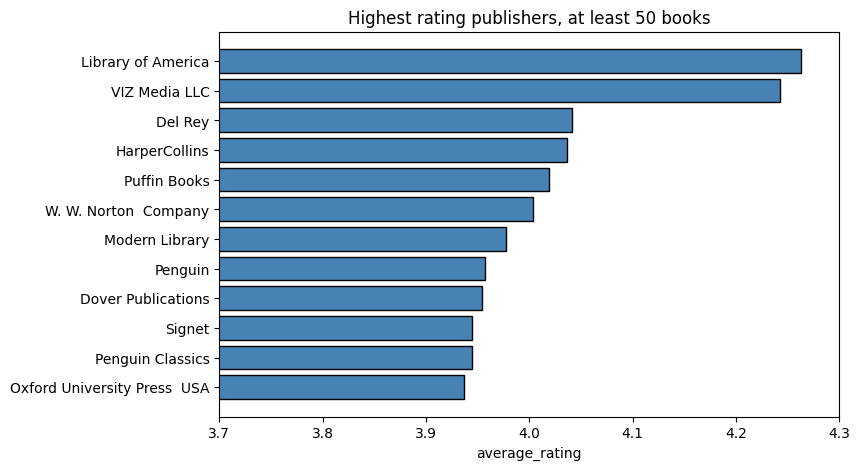

In [42]:
publisher_stats = df.groupby("publisher")["average_rating"].agg(["mean", "count"])
publisher_stats = publisher_stats[publisher_stats["count"] >= 50].sort_values("mean", ascending=False).head(12)
print(publisher_stats.round(3))
plt.figure(figsize=(8, 5))
plt.barh(publisher_stats.index[::-1], publisher_stats["mean"][::-1], color="steelblue", edgecolor="black")
plt.xlim(3.7, 4.3)
plt.xlabel("average_rating")
plt.title("Highest rating publishers, at least 50 books")
plt.show()

                     mean  count
first_author                    
J.R.R. Tolkien      4.223     51
Fyodor Dostoyevsky  4.197     37
C.S. Lewis          4.192     33
Rumiko Takahashi    4.190     38
P.G. Wodehouse      4.165     46
Jane Austen         4.157     33
Terry Pratchett     4.115     31
Roald Dahl          4.060     40
Stephen King        4.004     81
Mercedes Lackey     4.003     40
Mark Twain          3.969     31
Agatha Christie     3.958     45


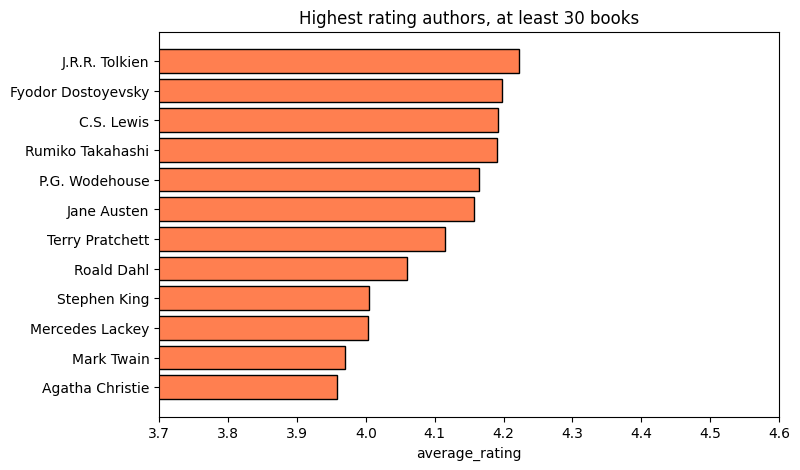

In [43]:
author_stats = df.groupby("first_author")["average_rating"].agg(["mean", "count"])
author_stats = author_stats[author_stats["count"] >= 30].sort_values("mean", ascending=False).head(12)
print(author_stats.round(3))
plt.figure(figsize=(8, 5))
plt.barh(author_stats.index[::-1], author_stats["mean"][::-1], color="coral", edgecolor="black")
plt.xlim(3.7, 4.6)
plt.xlabel("average_rating")
plt.title("Highest rating authors, at least 30 books")
plt.show()

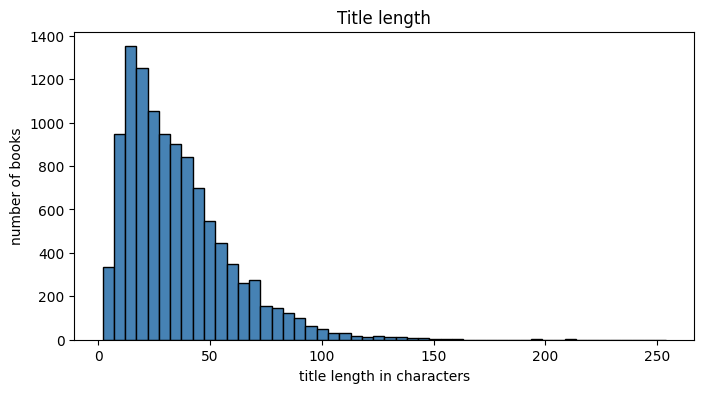

In [44]:
plt.figure(figsize=(8, 4))
plt.hist(df["title"].str.len(), bins=50, color="steelblue", edgecolor="black")
plt.xlabel("title length in characters")
plt.ylabel("number of books")
plt.title("Title length")
plt.show()

popularity_group
very low     3.903
low          3.934
medium       3.943
high         3.953
very high    3.984
Name: average_rating, dtype: float64


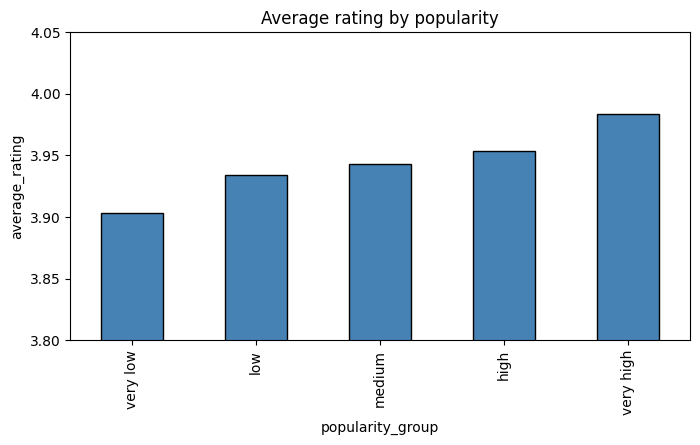

In [45]:
df["popularity_group"] = pd.qcut(df["ratings_count"], 5, labels=["very low", "low", "medium", "high", "very high"])
rating_by_popularity = df.groupby("popularity_group", observed=True)["average_rating"].mean()
print(rating_by_popularity.round(3))
plt.figure(figsize=(8, 4))
rating_by_popularity.plot.bar(color="steelblue", edgecolor="black")
plt.ylim(3.8, 4.05)
plt.ylabel("average_rating")
plt.title("Average rating by popularity")
plt.show()

In [46]:
popular = df[df["ratings_count"] >= 1000]
print("books with at least 1000 ratings:", len(popular))
print("their average rating:", round(popular["average_rating"].mean(), 3))
print("all books average rating:", round(df["average_rating"].mean(), 3))

books with at least 1000 ratings: 5109
their average rating: 3.964
all books average rating: 3.943


length_group
under 200      3.937
200 to 400     3.901
400 to 600     3.977
600 to 1000    4.070
over 1000      4.224
Name: average_rating, dtype: float64


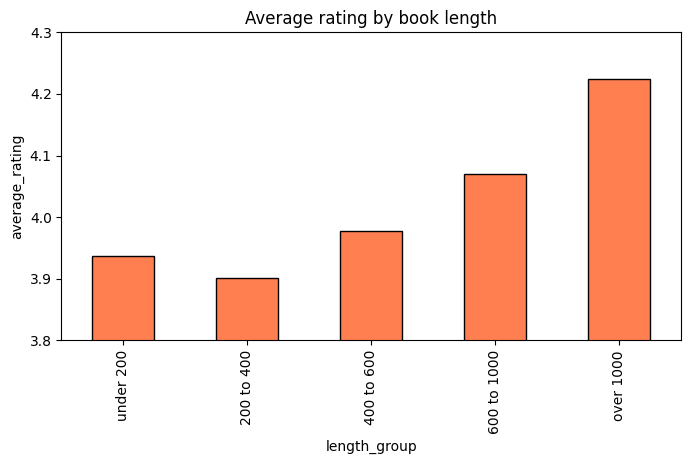

In [47]:
df["length_group"] = pd.cut(df["num_pages"], bins=[0, 200, 400, 600, 1000, 10000],
                            labels=["under 200", "200 to 400", "400 to 600", "600 to 1000", "over 1000"])
rating_by_length = df.groupby("length_group", observed=True)["average_rating"].mean()
print(rating_by_length.round(3))
plt.figure(figsize=(8, 4))
rating_by_length.plot.bar(color="coral", edgecolor="black")
plt.ylim(3.8, 4.3)
plt.ylabel("average_rating")
plt.title("Average rating by book length")
plt.show()

decade
1950    3.991
1960    3.959
1970    3.961
1980    3.979
1990    3.953
2000    3.936
2010    3.995
Name: average_rating, dtype: float64


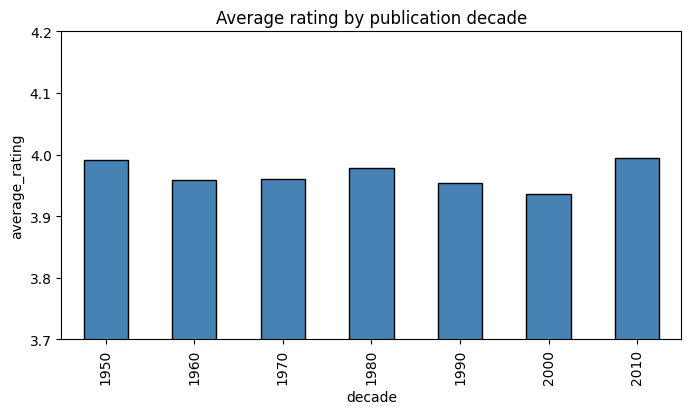

In [48]:
decade_books = df[df["pub_year"].between(1950, 2010)].copy()
decade_books["decade"] = (decade_books["pub_year"] // 10 * 10).astype(int)
rating_by_decade = decade_books.groupby("decade")["average_rating"].mean()
print(rating_by_decade.round(3))
plt.figure(figsize=(8, 4))
rating_by_decade.plot.bar(color="steelblue", edgecolor="black")
plt.ylim(3.7, 4.2)
plt.ylabel("average_rating")
plt.title("Average rating by publication decade")
plt.show()

In [49]:
df["title_core"] = df["title"].str.lower()
df["title_core"] = df["title_core"].str.replace(r"\(.*?\)|\[.*?\]", " ", regex=True)
df["title_core"] = df["title_core"].str.replace(r"[^a-z0-9 ]", " ", regex=True)
df["title_core"] = df["title_core"].str.replace(r"\s+", " ", regex=True).str.strip()
df["work_key"] = df["title_core"] + " :: " + df["first_author"].str.lower().fillna("")
df[["title", "work_key"]].head()

,title,work_key
0,Harry Potter and the Half-Blood Prince (Harry ...,harry potter and the half blood prince :: j.k....
1,Harry Potter and the Order of the Phoenix (Har...,harry potter and the order of the phoenix :: j...
2,Harry Potter and the Chamber of Secrets (Harry...,harry potter and the chamber of secrets :: j.k...
3,Harry Potter and the Prisoner of Azkaban (Harr...,harry potter and the prisoner of azkaban :: j....
4,Harry Potter Boxed Set Books 1-5 (Harry Potte...,harry potter boxed set books 1 5 :: j.k. rowling


In [50]:
df_sorted = df.sort_values("ratings_count", ascending=False)
works = df_sorted.drop_duplicates(subset="work_key", keep="first").copy()
works = works.reset_index(drop=True)
print("editions:", len(df))
print("works after keeping the most rated edition of each book:", len(works))

editions: 11012
works after keeping the most rated edition of each book: 10157


In [51]:
edition_counts = df["work_key"].value_counts()
works["n_editions"] = works["work_key"].map(edition_counts)
print("books that exist in more than one edition:", int((works["n_editions"] > 1).sum()))

books that exist in more than one edition: 547


In [52]:
works["num_pages_missing"] = works["num_pages"].isna().astype(int)
print("books with a missing page count:", int(works["num_pages_missing"].sum()))

books with a missing page count: 53


In [53]:
works["title_word_count"] = works["title"].str.split().str.len()
works["title_char_len"] = works["title"].str.len()
works["has_subtitle"] = works["title"].str.contains(":", regex=False).astype(int)
works["has_number_in_title"] = works["title"].str.contains(r"\d", regex=True).astype(int)
works[["title_word_count", "title_char_len", "has_subtitle", "has_number_in_title"]].head()

,title_word_count,title_char_len,has_subtitle,has_number_in_title
0,3,23,0,1
1,7,35,0,0
2,5,22,0,0
3,6,36,0,1
4,10,59,0,1


In [54]:
works["series_number"] = works["title"].str.extract(r"(\d+)\)\s*$")[0]
works["series_number"] = works["series_number"].fillna(0).astype(int)
works["is_series"] = (works["series_number"] > 0).astype(int)
print("books that are part of a numbered series:", int(works["is_series"].sum()))

books that are part of a numbered series: 2252


In [55]:
works["is_collection"] = works["title"].str.lower().str.contains("boxed set|box set|omnibus|collection|anthology").astype(int)
works["is_study_guide"] = works["title"].str.lower().str.contains("cliffsnotes|sparknotes|spark notes|study guide").astype(int)
print("collections:", int(works["is_collection"].sum()))
print("study guides:", int(works["is_study_guide"].sum()))

collections: 82
study guides: 31


In [56]:
works["num_authors"] = works["authors"].str.count("/") + 1
works["num_authors"].value_counts().sort_index().head()

num_authors
1    6119
2    2738
3     866
4     199
5      55
Name: count, dtype: int64

In [57]:
REFERENCE_YEAR = 2021
works["pub_quarter"] = works["pub_date"].dt.quarter
works["book_age"] = REFERENCE_YEAR - works["pub_year"]
works[["pub_year", "pub_quarter", "book_age"]].head()

,pub_year,pub_quarter,book_age
0,2006.0,3.0,15.0
1,2002.0,3.0,19.0
2,2001.0,1.0,20.0
3,2006.0,2.0,15.0
4,2004.0,2.0,17.0


In [58]:
works["log_ratings_count"] = np.log1p(works["ratings_count"])
works["log_text_reviews"] = np.log1p(works["text_reviews_count"])
works["reviews_per_rating"] = (works["text_reviews_count"] / works["ratings_count"]).clip(0, 1)
works[["log_ratings_count", "log_text_reviews", "reviews_per_rating"]].head()

,log_ratings_count,log_text_reviews,reviews_per_rating
0,15.341060,11.453876,0.020503
1,14.744084,10.400377,0.012988
2,14.714490,10.680516,0.017703
3,14.698756,9.966650,0.008807
4,14.665485,10.500289,0.015526


In [59]:
works["lang_group"] = "other"
works.loc[works["language_code"].str.startswith("en"), "lang_group"] = "english"
works.loc[works["language_code"].isin(["spa", "fre", "ger", "jpn"]), "lang_group"] = works["language_code"]
works["lang_group"].value_counts()

lang_group
english    9643
spa         187
fre         128
ger          91
other        64
jpn          44
Name: count, dtype: int64

In [60]:
works["publisher_norm"] = works["publisher"].str.lower()
works["publisher_norm"] = works["publisher_norm"].str.replace(r"[^a-z0-9 ]", " ", regex=True)
works["publisher_norm"] = works["publisher_norm"].str.replace(r"\b(inc|ltd|llc|co|company|books|book|publishing|publishers|publications|press|group|the)\b", " ", regex=True)
works["publisher_norm"] = works["publisher_norm"].str.replace(r"\s+", " ", regex=True).str.strip()
print("publishers before cleaning:", works["publisher"].nunique())
print("publishers after cleaning:", works["publisher_norm"].nunique())

publishers before cleaning: 2169
publishers after cleaning: 1844


In [61]:
author_book_count = works["first_author"].value_counts()
works["author_book_count"] = works["first_author"].map(author_book_count)
publisher_book_count = works["publisher_norm"].value_counts()
works["publisher_book_count"] = works["publisher_norm"].map(publisher_book_count)
print(works[["author_book_count", "publisher_book_count"]].describe().round(1))

       author_book_count  publisher_book_count
count            10157.0               10157.0
mean                 8.1                  57.9
std                  9.7                  80.2
min                  1.0                   1.0
25%                  1.0                   6.0
50%                  5.0                  25.0
75%                 11.0                  73.0
max                 59.0                 319.0


In [62]:
author_mean_ratings = works.groupby("first_author")["ratings_count"].mean()
works["author_avg_ratings"] = np.log1p(works["first_author"].map(author_mean_ratings))
print(works["author_avg_ratings"].describe().round(2))

count    10157.00
mean         7.78
std          2.50
min          0.69
25%          6.25
50%          8.09
75%          9.55
max         15.34
Name: author_avg_ratings, dtype: float64


In [63]:
numeric_features = ["num_pages", "num_pages_missing", "num_authors", "title_word_count", "title_char_len",
                    "has_subtitle", "has_number_in_title", "is_series", "series_number",
                    "is_collection", "is_study_guide", "book_age", "pub_quarter", "n_editions",
                    "author_book_count", "publisher_book_count", "author_avg_ratings",
                    "log_ratings_count", "log_text_reviews", "reviews_per_rating"]
target_encode_features = ["first_author", "publisher_norm"]
onehot_features = ["lang_group"]
feature_columns = numeric_features + target_encode_features + onehot_features
print("total features:", len(feature_columns))

total features: 23


In [64]:
X = works[feature_columns]
y = works["average_rating"].to_numpy()
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10157, 23)
y shape: (10157,)


In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("training rows:", len(X_train))
print("test rows:", len(X_test))

training rows: 8125
test rows: 2032


In [66]:
impute_numbers = SimpleImputer(strategy="median")
encode_authors_publishers = TargetEncoder(target_type="continuous", random_state=RANDOM_STATE)
encode_language = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(transformers=[
    ("numbers", impute_numbers, numeric_features),
    ("authors_publishers", encode_authors_publishers, target_encode_features),
    ("language", encode_language, onehot_features),
])

In [67]:
target_series = pd.Series(y_train, index=X_train.index)
correlation_with_target = X_train[numeric_features].corrwith(target_series).abs().sort_values(ascending=False)
print(correlation_with_target.round(3))

num_pages               0.161
reviews_per_rating      0.160
title_char_len          0.136
title_word_count        0.130
author_avg_ratings      0.124
has_number_in_title     0.114
log_ratings_count       0.109
has_subtitle            0.082
author_book_count       0.080
is_series               0.065
log_text_reviews        0.047
is_collection           0.047
book_age                0.043
num_authors             0.026
pub_quarter             0.023
publisher_book_count    0.020
series_number           0.014
n_editions              0.006
num_pages_missing       0.006
is_study_guide          0.004
dtype: float64


In [68]:
numeric_filled = X_train[numeric_features].fillna(X_train[numeric_features].median())
mi = mutual_info_regression(numeric_filled, y_train, random_state=RANDOM_STATE)
mi_scores = pd.Series(mi, index=numeric_features).sort_values(ascending=False)
print(mi_scores.round(4))

author_avg_ratings      0.1324
log_ratings_count       0.0643
reviews_per_rating      0.0622
author_book_count       0.0581
num_pages               0.0492
publisher_book_count    0.0351
title_char_len          0.0335
log_text_reviews        0.0249
title_word_count        0.0243
series_number           0.0183
has_number_in_title     0.0177
book_age                0.0162
has_subtitle            0.0075
n_editions              0.0049
is_study_guide          0.0048
is_series               0.0027
num_pages_missing       0.0003
num_authors             0.0000
is_collection           0.0000
pub_quarter             0.0000
dtype: float64


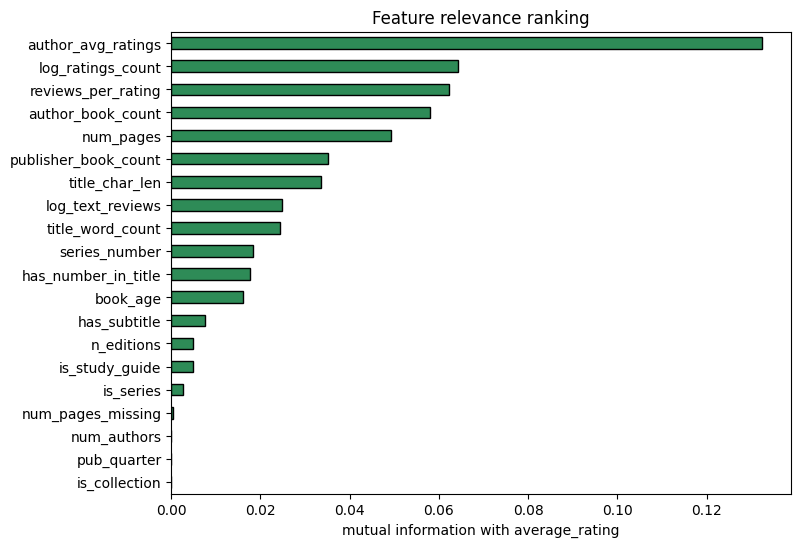

In [69]:
plt.figure(figsize=(8, 6))
mi_scores.sort_values().plot.barh(color="seagreen", edgecolor="black")
plt.xlabel("mutual information with average_rating")
plt.title("Feature relevance ranking")
plt.show()

In [70]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error", "r2": "r2"}
results = []

In [71]:
mean_prediction = np.full(len(y_test), y_train.mean())
print("baseline RMSE:", round(mean_squared_error(y_test, mean_prediction) ** 0.5, 4))
print("baseline MAE:", round(mean_absolute_error(y_test, mean_prediction), 4))
print("baseline R2:", round(r2_score(y_test, mean_prediction), 4))

baseline RMSE: 0.307
baseline MAE: 0.2286
baseline R2: -0.0


In [72]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", LinearRegression())])
scores = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)
print("Linear Regression   R2", round(scores["test_r2"].mean(), 3), "  RMSE", round(-scores["test_rmse"].mean(), 4))
results.append(["LinearRegression", -scores["test_rmse"].mean(), -scores["test_mae"].mean(), scores["test_r2"].mean(), scores["test_r2"].std()])

Linear Regression   R2 0.257   RMSE 0.2553


In [73]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", Ridge(alpha=10.0))])
scores = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)
print("Ridge   R2", round(scores["test_r2"].mean(), 3), "  RMSE", round(-scores["test_rmse"].mean(), 4))
results.append(["Ridge", -scores["test_rmse"].mean(), -scores["test_mae"].mean(), scores["test_r2"].mean(), scores["test_r2"].std()])

Ridge   R2 0.259   RMSE 0.2551


In [74]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", Lasso(alpha=0.001))])
scores = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)
print("Lasso   R2", round(scores["test_r2"].mean(), 3), "  RMSE", round(-scores["test_rmse"].mean(), 4))
results.append(["Lasso", -scores["test_rmse"].mean(), -scores["test_mae"].mean(), scores["test_r2"].mean(), scores["test_r2"].std()])

Lasso   R2 0.259   RMSE 0.255


In [75]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", ElasticNet(alpha=0.001, l1_ratio=0.5))])
scores = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)
print("ElasticNet   R2", round(scores["test_r2"].mean(), 3), "  RMSE", round(-scores["test_rmse"].mean(), 4))
results.append(["ElasticNet", -scores["test_rmse"].mean(), -scores["test_mae"].mean(), scores["test_r2"].mean(), scores["test_r2"].std()])

ElasticNet   R2 0.259   RMSE 0.255


In [76]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", KNeighborsRegressor(n_neighbors=15))])
scores = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)
print("KNN   R2", round(scores["test_r2"].mean(), 3), "  RMSE", round(-scores["test_rmse"].mean(), 4))
results.append(["KNN", -scores["test_rmse"].mean(), -scores["test_mae"].mean(), scores["test_r2"].mean(), scores["test_r2"].std()])

KNN   R2 0.21   RMSE 0.2633


In [77]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE))])
scores = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)
print("Decision Tree   R2", round(scores["test_r2"].mean(), 3), "  RMSE", round(-scores["test_rmse"].mean(), 4))
results.append(["DecisionTree", -scores["test_rmse"].mean(), -scores["test_mae"].mean(), scores["test_r2"].mean(), scores["test_r2"].std()])

Decision Tree   R2 0.11   RMSE 0.2794


In [78]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))])
scores = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)
print("Random Forest   R2", round(scores["test_r2"].mean(), 3), "  RMSE", round(-scores["test_rmse"].mean(), 4))
results.append(["RandomForest", -scores["test_rmse"].mean(), -scores["test_mae"].mean(), scores["test_r2"].mean(), scores["test_r2"].std()])

Random Forest   R2 0.255   RMSE 0.2555


In [79]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", ExtraTreesRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))])
scores = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)
print("Extra Trees   R2", round(scores["test_r2"].mean(), 3), "  RMSE", round(-scores["test_rmse"].mean(), 4))
results.append(["ExtraTrees", -scores["test_rmse"].mean(), -scores["test_mae"].mean(), scores["test_r2"].mean(), scores["test_r2"].std()])

Extra Trees   R2 0.255   RMSE 0.2557


In [80]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))])
scores = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)
print("Gradient Boosting   R2", round(scores["test_r2"].mean(), 3), "  RMSE", round(-scores["test_rmse"].mean(), 4))
results.append(["GradientBoosting", -scores["test_rmse"].mean(), -scores["test_mae"].mean(), scores["test_r2"].mean(), scores["test_r2"].std()])

Gradient Boosting   R2 0.266   RMSE 0.2538


In [81]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))])
scores = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)
print("Hist Gradient Boosting   R2", round(scores["test_r2"].mean(), 3), "  RMSE", round(-scores["test_rmse"].mean(), 4))
results.append(["HistGradientBoosting", -scores["test_rmse"].mean(), -scores["test_mae"].mean(), scores["test_r2"].mean(), scores["test_r2"].std()])

Hist Gradient Boosting   R2 0.271   RMSE 0.253


In [82]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", AdaBoostRegressor(random_state=RANDOM_STATE))])
scores = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)
print("AdaBoost   R2", round(scores["test_r2"].mean(), 3), "  RMSE", round(-scores["test_rmse"].mean(), 4))
results.append(["AdaBoost", -scores["test_rmse"].mean(), -scores["test_mae"].mean(), scores["test_r2"].mean(), scores["test_r2"].std()])

AdaBoost   R2 0.031   RMSE 0.2915


In [83]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", SVR(C=1.0))])
scores = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)
print("SVR   R2", round(scores["test_r2"].mean(), 3), "  RMSE", round(-scores["test_rmse"].mean(), 4))
results.append(["SVR", -scores["test_rmse"].mean(), -scores["test_mae"].mean(), scores["test_r2"].mean(), scores["test_r2"].std()])

SVR   R2 0.278   RMSE 0.2517


In [84]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, verbose=0, random_state=RANDOM_STATE))])
scores = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)
print("CatBoost   R2", round(scores["test_r2"].mean(), 3), "  RMSE", round(-scores["test_rmse"].mean(), 4))
results.append(["CatBoost", -scores["test_rmse"].mean(), -scores["test_mae"].mean(), scores["test_r2"].mean(), scores["test_r2"].std()])

CatBoost   R2 0.286   RMSE 0.2503


In [85]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0))])
scores = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)
print("XGBoost   R2", round(scores["test_r2"].mean(), 3), "  RMSE", round(-scores["test_rmse"].mean(), 4))
results.append(["XGBoost", -scores["test_rmse"].mean(), -scores["test_mae"].mean(), scores["test_r2"].mean(), scores["test_r2"].std()])

XGBoost   R2 0.265   RMSE 0.2539


In [86]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", LGBMRegressor(n_estimators=400, learning_rate=0.05, n_jobs=-1, verbose=-1))])
scores = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)
print("LightGBM   R2", round(scores["test_r2"].mean(), 3), "  RMSE", round(-scores["test_rmse"].mean(), 4))
results.append(["LightGBM", -scores["test_rmse"].mean(), -scores["test_mae"].mean(), scores["test_r2"].mean(), scores["test_r2"].std()])

LightGBM   R2 0.253   RMSE 0.256


In [87]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", MLPRegressor(hidden_layer_sizes=(100,), max_iter=600, early_stopping=True, n_iter_no_change=25, alpha=0.01, random_state=RANDOM_STATE))])
scores = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)
print("Neural Network   R2", round(scores["test_r2"].mean(), 3), "  RMSE", round(-scores["test_rmse"].mean(), 4))
results.append(["NeuralNetwork", -scores["test_rmse"].mean(), -scores["test_mae"].mean(), scores["test_r2"].mean(), scores["test_r2"].std()])

Neural Network   R2 0.077   RMSE 0.2842


In [88]:
comparison = pd.DataFrame(results, columns=["model", "rmse", "mae", "r2", "r2_std"])
comparison = comparison.set_index("model").sort_values("rmse")
comparison.round(4)

,rmse,mae,r2,r2_std
model,,,,
CatBoost,0.2503,0.1812,0.2860,0.0307
SVR,0.2517,0.1825,0.2783,0.0191
HistGradientBoosting,0.2530,0.1811,0.2705,0.0381
GradientBoosting,0.2538,0.1831,0.2656,0.0375
XGBoost,0.2539,0.1815,0.2650,0.0464
ElasticNet,0.2550,0.1866,0.2588,0.0270
Lasso,0.2550,0.1866,0.2588,0.0268
Ridge,0.2551,0.1866,0.2585,0.0273
LinearRegression,0.2553,0.1869,0.2571,0.0264


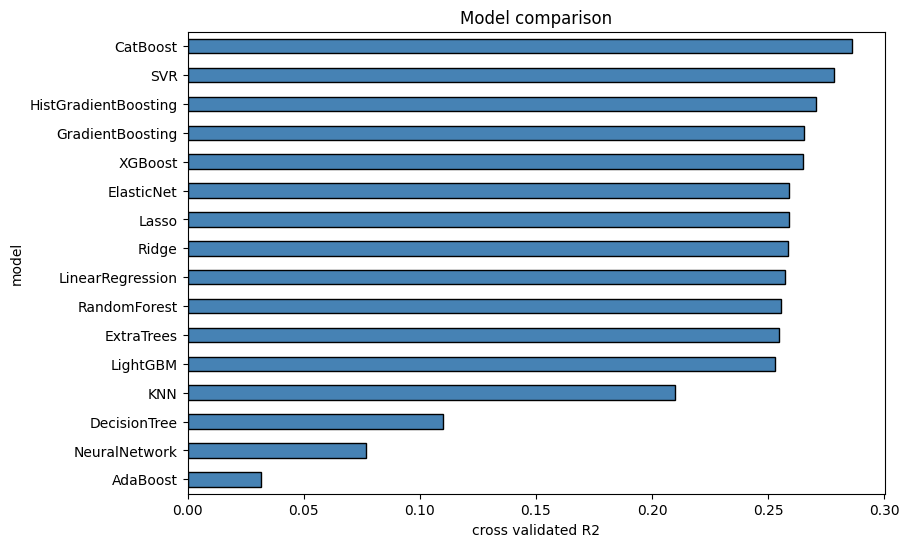

In [89]:
plt.figure(figsize=(9, 6))
comparison["r2"].sort_values().plot.barh(color="steelblue", edgecolor="black")
plt.xlabel("cross validated R2")
plt.title("Model comparison")
plt.show()

In [90]:
parameter_grid = {
    "model__depth": [4, 6],
    "model__learning_rate": [0.03, 0.06],
}
catboost_pipeline = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()),
                              ("model", CatBoostRegressor(iterations=400, verbose=0, random_state=RANDOM_STATE))])
grid = GridSearchCV(catboost_pipeline, parameter_grid, cv=kfold, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train)
print("number of combinations tried:", len(grid.cv_results_["params"]))
print("best parameters:", grid.best_params_)
print("best cross validated RMSE:", round(-grid.best_score_, 4))

number of combinations tried: 4
best parameters: {'model__depth': 4, 'model__learning_rate': 0.03}
best cross validated RMSE: 0.2503


In [91]:
best_params = {key.replace("model__", ""): value for key, value in grid.best_params_.items()}
print(best_params)

{'depth': 4, 'learning_rate': 0.03}


In [92]:
best_model = grid.best_estimator_
test_prediction = np.clip(best_model.predict(X_test), 0, 5)
test_rmse = mean_squared_error(y_test, test_prediction) ** 0.5
test_mae = mean_absolute_error(y_test, test_prediction)
test_r2 = r2_score(y_test, test_prediction)
print("tuned CatBoost on the test set")
print("RMSE:", round(test_rmse, 4))
print("MAE:", round(test_mae, 4))
print("R2:", round(test_r2, 4))

tuned CatBoost on the test set
RMSE: 0.2542
MAE: 0.1784
R2: 0.3148


In [93]:
train_prediction = best_model.predict(X_train)
print("train R2:", round(r2_score(y_train, train_prediction), 4))
print("test R2:", round(test_r2, 4))

train R2: 0.669
test R2: 0.3148


In [94]:
robust_scores = cross_validate(best_model, X, y, cv=kfold, scoring=scoring)
print("five fold R2 mean:", round(robust_scores["test_r2"].mean(), 4))
print("five fold R2 std:", round(robust_scores["test_r2"].std(), 4))
print("five fold RMSE mean:", round(-robust_scores["test_rmse"].mean(), 4))

five fold R2 mean: 0.3057
five fold R2 std: 0.0043
five fold RMSE mean: 0.2487


In [95]:
author_groups = works["first_author"].fillna("unknown")
normal_cv = cross_val_score(best_model, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), scoring="r2")
unseen_author_cv = cross_val_score(best_model, X, y, cv=GroupKFold(n_splits=5), groups=author_groups, scoring="r2")
print("R2 with normal cross validation, authors can appear in train and test:", round(normal_cv.mean(), 4))
print("R2 for books written by authors never seen in training:", round(unseen_author_cv.mean(), 4))

R2 with normal cross validation, authors can appear in train and test: 0.3057
R2 for books written by authors never seen in training: 0.1398


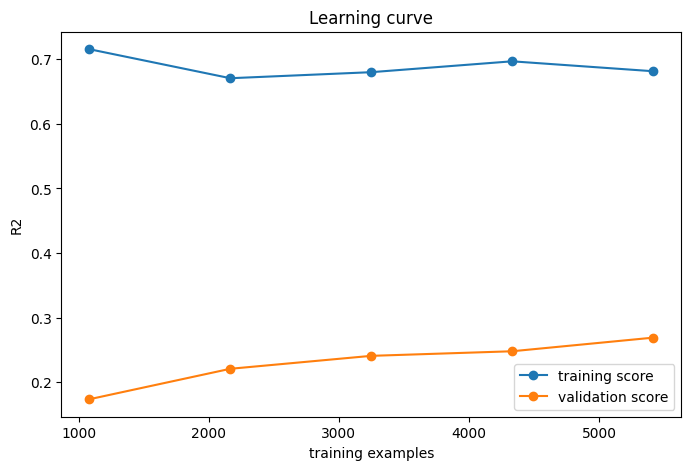

In [96]:
sizes, train_curve, val_curve = learning_curve(best_model, X_train, y_train, cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE), scoring="r2", train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1)
plt.figure(figsize=(8, 5))
plt.plot(sizes, train_curve.mean(axis=1), marker="o", label="training score")
plt.plot(sizes, val_curve.mean(axis=1), marker="o", label="validation score")
plt.xlabel("training examples")
plt.ylabel("R2")
plt.title("Learning curve")
plt.legend()
plt.show()

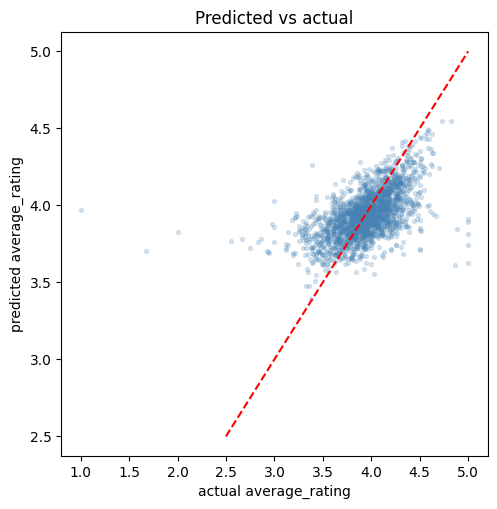

In [97]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test, test_prediction, s=8, alpha=0.2, color="steelblue")
plt.plot([2.5, 5.0], [2.5, 5.0], "r--")
plt.xlabel("actual average_rating")
plt.ylabel("predicted average_rating")
plt.title("Predicted vs actual")
plt.show()

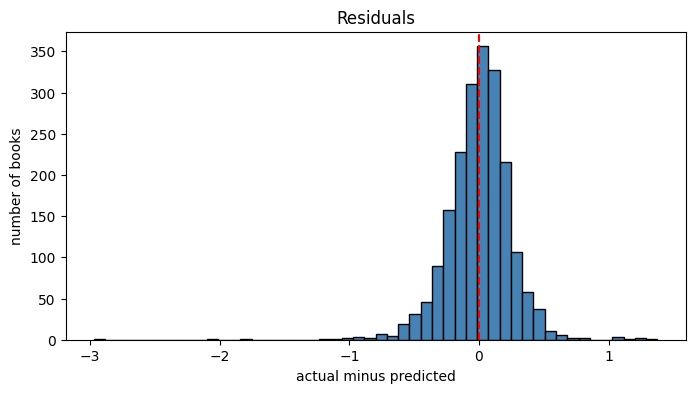

residual mean: -0.0002
residual std: 0.2542


In [98]:
residuals = y_test - test_prediction
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, color="steelblue", edgecolor="black")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("actual minus predicted")
plt.ylabel("number of books")
plt.title("Residuals")
plt.show()
print("residual mean:", round(float(residuals.mean()), 4))
print("residual std:", round(float(residuals.std()), 4))

In [99]:
errors = pd.DataFrame({
    "title": works.loc[X_test.index, "title"].values,
    "actual": y_test,
    "predicted": np.round(test_prediction, 2),
})
errors["abs_error"] = (errors["actual"] - errors["predicted"]).abs().round(2)
worst = errors.sort_values("abs_error", ascending=False).head(10)
print(worst.to_string(index=False))

                                                                                        title  actual  predicted  abs_error
                                                                         Mandala Sand Art Kit    1.00       3.97       2.97
                           The Art of Loving by Erich Fromm: A True Story of a Japanese Woman    1.67       3.70       2.03
                       The Halloween Activity Book: Creepy  Crawly  Hairy  Scary Things to Do    2.00       3.83       1.83
  Oliver Wendell Holmes in Paris: Medicine  Theology  and the Autocrat of the Breakfast Table    5.00       3.62       1.38
Delwau Duon: Peintiadau Nicholas Evans = Symphonies in Black: The Paintings of Nicholas Evans    5.00       3.74       1.26
                                                                      Stargirl LitPlans on CD    4.86       3.61       1.25
                         The Trouble with the Pears: An Intimate Portrait of Erzsebet Bathory    2.55       3.77       1.22
        

In [100]:
importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring="r2")
importance_scores = pd.Series(importance.importances_mean, index=X_test.columns).sort_values(ascending=False)
importance_scores.round(4)

first_author            0.2466
num_pages               0.0684
reviews_per_rating      0.0354
publisher_norm          0.0282
title_char_len          0.0150
author_avg_ratings      0.0086
book_age                0.0075
log_ratings_count       0.0043
num_authors             0.0041
author_book_count       0.0040
title_word_count        0.0035
has_subtitle            0.0027
series_number           0.0017
log_text_reviews        0.0015
is_collection           0.0011
publisher_book_count    0.0011
lang_group              0.0008
num_pages_missing       0.0004
is_series               0.0003
has_number_in_title     0.0002
n_editions              0.0000
is_study_guide          0.0000
pub_quarter            -0.0003
dtype: float64

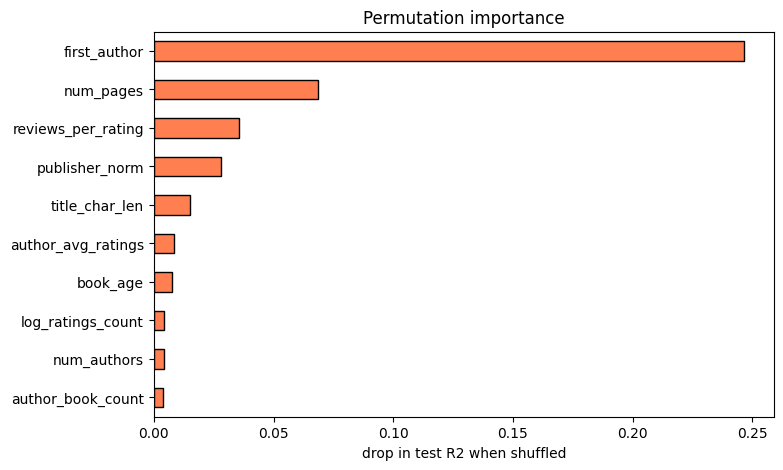

In [101]:
plt.figure(figsize=(8, 5))
importance_scores.head(10).sort_values().plot.barh(color="coral", edgecolor="black")
plt.xlabel("drop in test R2 when shuffled")
plt.title("Permutation importance")
plt.show()

In [102]:
transformed_test = best_model[:-1].transform(X_test)
feature_names = best_model[:-1].get_feature_names_out()
transformed_test = pd.DataFrame(transformed_test, columns=feature_names)
trained_model = best_model.named_steps["model"]
explainer = shap.TreeExplainer(trained_model)
shap_values = explainer(transformed_test)
print("shap values computed for", transformed_test.shape[0], "books")

shap values computed for 2032 books


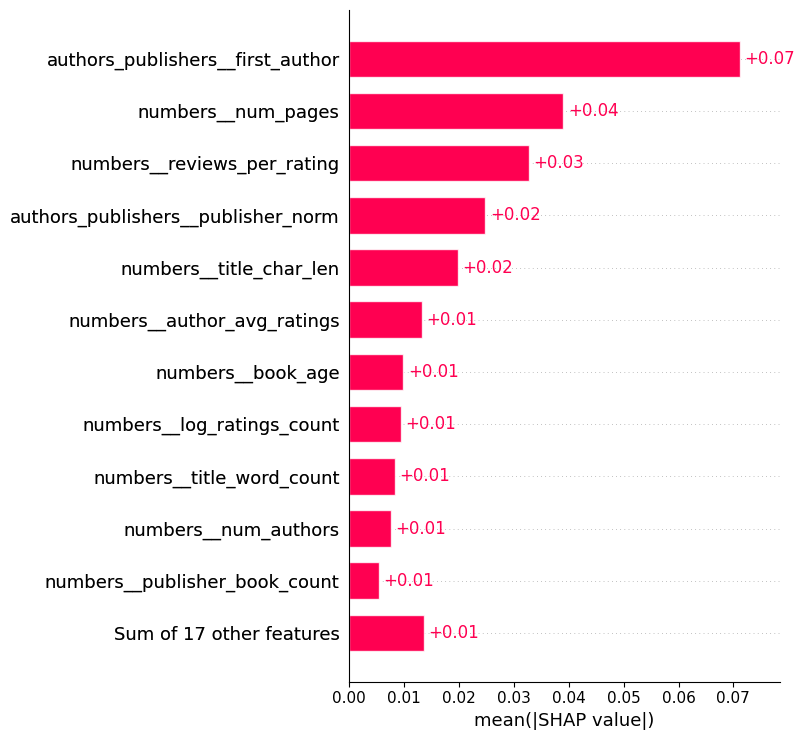

In [103]:
shap.plots.bar(shap_values, max_display=12, show=False)
plt.tight_layout()
plt.show()

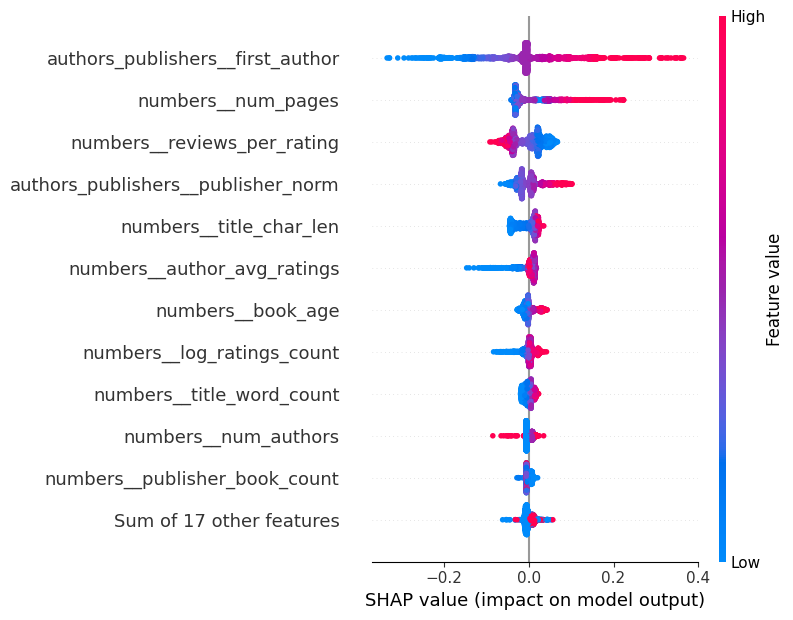

In [104]:
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.tight_layout()
plt.show()

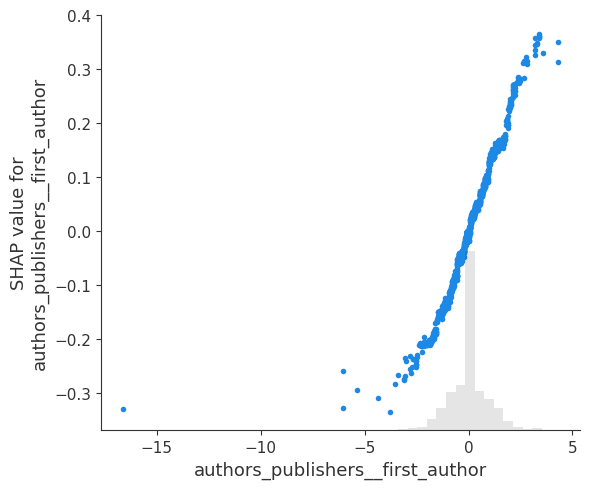

In [105]:
author_feature = [n for n in shap_values.feature_names if "first_author" in n][0]
shap.plots.scatter(shap_values[:, author_feature], show=False)
plt.tight_layout()
plt.show()

In [106]:
X_with_popularity = works[feature_columns]
Xa, Xb, ya, yb = train_test_split(X_with_popularity, y, test_size=0.2, random_state=RANDOM_STATE)
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()),
                  ("model", CatBoostRegressor(iterations=400, verbose=0, random_state=RANDOM_STATE, **best_params))])
model.fit(Xa, ya)
r2_with_popularity = r2_score(yb, model.predict(Xb))
print("with popularity features, test R2:", round(r2_with_popularity, 4))

with popularity features, test R2: 0.3148


In [107]:
numeric_without_popularity = [c for c in numeric_features if c not in ["log_ratings_count", "log_text_reviews", "reviews_per_rating", "author_avg_ratings"]]
features_intrinsic = numeric_without_popularity + target_encode_features + onehot_features
impute_intrinsic = SimpleImputer(strategy="median")
encode_authors_intrinsic = TargetEncoder(target_type="continuous", random_state=RANDOM_STATE)
encode_language_intrinsic = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
preprocessor_intrinsic = ColumnTransformer(transformers=[
    ("numbers", impute_intrinsic, numeric_without_popularity),
    ("authors_publishers", encode_authors_intrinsic, target_encode_features),
    ("language", encode_language_intrinsic, onehot_features),
])
X_intrinsic = works[features_intrinsic]
Xa, Xb, ya, yb = train_test_split(X_intrinsic, y, test_size=0.2, random_state=RANDOM_STATE)
model = Pipeline([("prep", preprocessor_intrinsic), ("scaler", StandardScaler()),
                  ("model", CatBoostRegressor(iterations=400, verbose=0, random_state=RANDOM_STATE, **best_params))])
model.fit(Xa, ya)
r2_intrinsic = r2_score(yb, model.predict(Xb))
print("intrinsic features only, test R2:", round(r2_intrinsic, 4))

intrinsic features only, test R2: 0.2882


In [108]:
Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()),
                  ("model", CatBoostRegressor(iterations=400, verbose=0, random_state=RANDOM_STATE, **best_params))])
model.fit(Xa, ya)
r2_all = r2_score(yb, model.predict(Xb))
print("all books, test R2:", round(r2_all, 4), " test rows:", len(yb))

all books, test R2: 0.3148  test rows: 2032


In [109]:
mask = works["ratings_count"] >= 25
X_subset = X[mask.values]
y_subset = y[mask.values]
Xa, Xb, ya, yb = train_test_split(X_subset, y_subset, test_size=0.2, random_state=RANDOM_STATE)
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()),
                  ("model", CatBoostRegressor(iterations=400, verbose=0, random_state=RANDOM_STATE, **best_params))])
model.fit(Xa, ya)
r2_25 = r2_score(yb, model.predict(Xb))
print("ratings_count >= 25, test R2:", round(r2_25, 4), " test rows:", len(yb))

ratings_count >= 25, test R2: 0.3895  test rows: 1818


In [110]:
mask = works["ratings_count"] >= 50
X_subset = X[mask.values]
y_subset = y[mask.values]
Xa, Xb, ya, yb = train_test_split(X_subset, y_subset, test_size=0.2, random_state=RANDOM_STATE)
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()),
                  ("model", CatBoostRegressor(iterations=400, verbose=0, random_state=RANDOM_STATE, **best_params))])
model.fit(Xa, ya)
r2_50 = r2_score(yb, model.predict(Xb))
print("ratings_count >= 50, test R2:", round(r2_50, 4), " test rows:", len(yb))

ratings_count >= 50, test R2: 0.376  test rows: 1712


In [111]:
mask = works["ratings_count"] >= 100
X_subset = X[mask.values]
y_subset = y[mask.values]
Xa, Xb, ya, yb = train_test_split(X_subset, y_subset, test_size=0.2, random_state=RANDOM_STATE)
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()),
                  ("model", CatBoostRegressor(iterations=400, verbose=0, random_state=RANDOM_STATE, **best_params))])
model.fit(Xa, ya)
r2_100 = r2_score(yb, model.predict(Xb))
print("ratings_count >= 100, test R2:", round(r2_100, 4), " test rows:", len(yb))

ratings_count >= 100, test R2: 0.4152  test rows: 1568


                  test_r2
subset                   
all books          0.3148
ratings 25 plus    0.3895
ratings 50 plus    0.3760
ratings 100 plus   0.4152


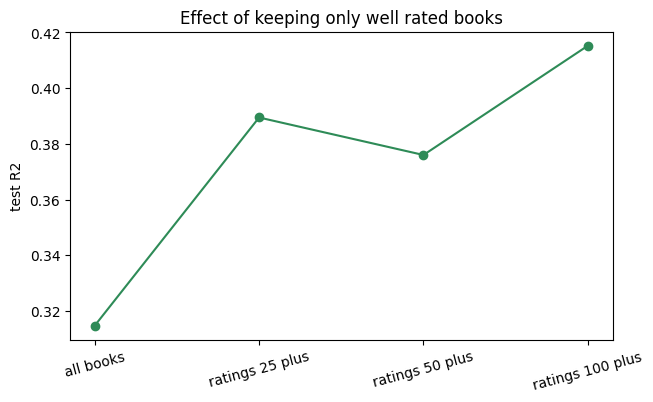

In [112]:
sensitivity = pd.DataFrame({
    "subset": ["all books", "ratings 25 plus", "ratings 50 plus", "ratings 100 plus"],
    "test_r2": [r2_all, r2_25, r2_50, r2_100],
})
sensitivity = sensitivity.set_index("subset")
print(sensitivity.round(4))
plt.figure(figsize=(7, 4))
plt.plot(range(len(sensitivity)), sensitivity["test_r2"], marker="o", color="seagreen")
plt.xticks(range(len(sensitivity)), sensitivity.index, rotation=15)
plt.ylabel("test R2")
plt.title("Effect of keeping only well rated books")
plt.show()

In [113]:
joblib.dump(best_model, "book_rating_model.joblib")
print("model saved")

model saved


In [114]:
loaded_model = joblib.load("book_rating_model.joblib")
example = X_test.head(5)
example_titles = works.loc[example.index, "title"]
predicted_ratings = loaded_model.predict(example)
result_table = pd.DataFrame({
    "title": example_titles.values,
    "actual": np.round(y_test[:5], 2),
    "predicted": np.round(predicted_ratings, 2),
})
result_table

,title,actual,predicted
0,On Death and Dying,4.16,3.94
1,Losing Battles,3.60,3.96
2,Master of Wolves (Mageverse #3),4.17,3.99
3,Let My People Go Surfing: The Education of a R...,4.22,3.89
4,Perfect Nightmare,3.89,3.79


In [115]:
print("SUMMARY OF RESULTS")
print("baseline R2 predicting the mean       :", round(r2_score(y_test, mean_prediction), 3))
print("tuned model R2 on all books           :", round(test_r2, 3))
print("tuned model R2 for unseen authors     :", round(unseen_author_cv.mean(), 3))
print("tuned model R2 for well rated books   :", round(r2_100, 3))
print()
print("the strongest signal is the identity of the author and publisher")
print("ratings_count, text_reviews and editions only exist after a book is published and rated")
print("so predicting a brand new book before it has any ratings is much harder, around", round(unseen_author_cv.mean(), 2))
print("the realistic ceiling for this dataset is roughly 0.3 to 0.4 depending on how many ratings a book has")

SUMMARY OF RESULTS
baseline R2 predicting the mean       : -0.0
tuned model R2 on all books           : 0.315
tuned model R2 for unseen authors     : 0.14
tuned model R2 for well rated books   : 0.415

the strongest signal is the identity of the author and publisher
ratings_count, text_reviews and editions only exist after a book is published and rated
so predicting a brand new book before it has any ratings is much harder, around 0.14
the realistic ceiling for this dataset is roughly 0.3 to 0.4 depending on how many ratings a book has
